# Business understanding

**Goals :** Meningkatkan Profit dan meminimalisir return produk

# Import Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Read Dataset

In [ ]:
fmcg = pd.read_csv('https://raw.githubusercontent.com/rezanagita/fmcg-analytics/refs/heads/main/fmcg_clean.csv')
fmcg.head()

,Invoice_No,retailer_id,sales_date,city,sku_category,brand,Units_Sold,Unit_Price,discount_pct,Sales_Value,COGS,outlet_type,Sales_Channel,Customer_Age,loyalty_flag,return_flag,Target_Sales
0,FMC-000001,RTL1965,2025-08-21,Bandung,Food,Brand B,1,797.24,0.50,914.85,912.85,General Trade,Distributor,67,N,Y,108312
1,FMC-000002,Unknown,2025-08-08,Jakarta,Household,Brand A,3573,131.59,0.05,446663.00,242658.00,General Trade,Online,36,N,N,490592
2,FMC-000003,Unknown,2024-09-12,Yogyakarta,Food,Brand B,13,517.66,0.20,5383.66,3564.95,General Trade,Online,56,N,Y,432032
3,FMC-000004,RTL1193,2025-03-31,Yogyakarta,Household,Brand B,8,321.69,0.95,128.68,164.39,General Trade,Offline,67,N,N,71174
4,FMC-000005,RTL3648,2024-03-26,Bandung,Personal Care,Brand A,10,877.23,0.20,7017.84,5105.24,General Trade,Online,58,Y,Y,250452


In [ ]:
fmcg.shape

(10000, 17)

# Check Data

In [ ]:
fmcg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_No     10000 non-null  object 
 1   retailer_id    10000 non-null  object 
 2   sales_date     10000 non-null  object 
 3   city           10000 non-null  object 
 4   sku_category   10000 non-null  object 
 5   brand          10000 non-null  object 
 6   Units_Sold     10000 non-null  int64  
 7   Unit_Price     10000 non-null  float64
 8   discount_pct   10000 non-null  float64
 9   Sales_Value    10000 non-null  float64
 10  COGS           10000 non-null  float64
 11  outlet_type    10000 non-null  object 
 12  Sales_Channel  10000 non-null  object 
 13  Customer_Age   10000 non-null  int64  
 14  loyalty_flag   10000 non-null  object 
 15  return_flag    10000 non-null  object 
 16  Target_Sales   10000 non-null  int64  
dtypes: float64(4), int64(3), object(10)
memory usage: 1

In [ ]:
# ubah tipe data sales_date
fmcg['sales_date'] = pd.to_datetime(fmcg['sales_date'])

In [ ]:
fmcg.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice_No,10000,9618,FMC-000067,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
retailer_id,10000,3622,Unknown,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_date,10000,NaN,NaN,NaN,2025-01-30 22:55:37.920000,2023-09-03 00:00:00,2024-05-20 00:00:00,2025-02-05 00:00:00,2025-10-14 00:00:00,2026-06-19 00:00:00,NaN
city,10000,4,Yogyakarta,2560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku_category,10000,3,Food,5985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,10000,3,Brand B,5078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Units_Sold,10000.0,NaN,NaN,NaN,50.8464,1.0,6.0,11.0,16.0,4958.0,369.711626
Unit_Price,10000.0,NaN,NaN,NaN,1768.41112,10.0,259.875,513.42,764.56,149383.0,11230.600221
discount_pct,10000.0,NaN,NaN,NaN,0.309685,0.0,0.05,0.15,0.5,0.95,0.331814
Sales_Value,10000.0,NaN,NaN,NaN,96122.04201,0.98,684.04,2413.705,6127.06,390526016.0,4532105.851198


In [ ]:
def audit (fmcg) :
  return pd.DataFrame({
      'dtype' : fmcg.dtypes,
      'nulls' : fmcg.isnull().sum(),
      'null_%' : (fmcg.isnull().mean()*100).round(2),
      'unique_%' : (fmcg.nunique()/len(fmcg)*100).round(2),
      'zeros' : (fmcg ==0).sum(),
      'sample' : fmcg.iloc[0]
  })

audit(fmcg)

,dtype,nulls,null_%,unique_%,zeros,sample
Invoice_No,object,0,0.0,96.18,0,FMC-000001
retailer_id,object,0,0.0,36.22,0,RTL1965
sales_date,datetime64[ns],0,0.0,10.21,0,2025-08-21 00:00:00
city,object,0,0.0,0.04,0,Bandung
sku_category,object,0,0.0,0.03,0,Food
brand,object,0,0.0,0.03,0,Brand B
Units_Sold,int64,0,0.0,1.66,0,1
Unit_Price,float64,0,0.0,95.10,0,797.24
discount_pct,float64,0,0.0,0.08,1927,0.5
Sales_Value,float64,0,0.0,99.01,0,914.85


<Axes: >

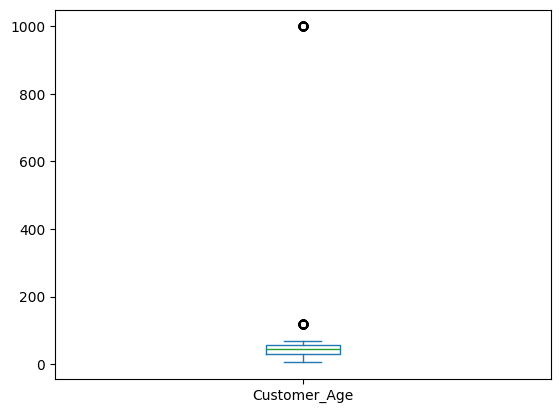

In [ ]:
# check outlier di Customer_Age
fmcg['Customer_Age'].plot(kind='box')

In [ ]:
Q1 = fmcg['Customer_Age'].quantile(0.25)
Q3 = fmcg['Customer_Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Melihat data yang merupakan outlier
outliers = fmcg[(fmcg['Customer_Age'] < lower_bound) | (fmcg['Customer_Age'] > upper_bound)]
outliers['Customer_Age'].value_counts()

,count
Customer_Age,
120,63
999,61


In [ ]:
# hapus outlier
Q1 = fmcg['Customer_Age'].quantile(0.25)
Q3 = fmcg['Customer_Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Menghapus data yang merupakan outlier
fmcg = fmcg[(fmcg['Customer_Age'] >= lower_bound) & (fmcg['Customer_Age'] <= upper_bound)]
fmcg['Customer_Age'].describe()

,Customer_Age
count,9876.000000
mean,43.691069
std,15.566704
min,5.000000
25%,30.000000
50%,44.000000
75%,57.000000
max,70.000000


In [ ]:
fmcg = fmcg[fmcg['Customer_Age'] != 5]

# Feature Engineering

Dataset dari 2023-09-03 - 2026-06-19

In [ ]:
fmcg

,Invoice_No,retailer_id,sales_date,city,sku_category,brand,Units_Sold,Unit_Price,discount_pct,Sales_Value,COGS,outlet_type,Sales_Channel,Customer_Age,loyalty_flag,return_flag,Target_Sales
0,FMC-000001,RTL1965,2025-08-21,Bandung,Food,Brand B,1,797.24,0.50,914.85,912.85,General Trade,Distributor,67,N,Y,108312
1,FMC-000002,Unknown,2025-08-08,Jakarta,Household,Brand A,3573,131.59,0.05,446663.00,242658.00,General Trade,Online,36,N,N,490592
2,FMC-000003,Unknown,2024-09-12,Yogyakarta,Food,Brand B,13,517.66,0.20,5383.66,3564.95,General Trade,Online,56,N,Y,432032
3,FMC-000004,RTL1193,2025-03-31,Yogyakarta,Household,Brand B,8,321.69,0.95,128.68,164.39,General Trade,Offline,67,N,N,71174
4,FMC-000005,RTL3648,2024-03-26,Bandung,Personal Care,Brand A,10,877.23,0.20,7017.84,5105.24,General Trade,Online,58,Y,Y,250452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,FMC-009996,RTL2985,2023-11-24,Bandung,Personal Care,Brand C,6,68.15,0.95,13.04,16.19,General Trade,Distributor,53,Y,Y,62889
9996,FMC-009997,RTL3712,2025-07-19,Bandung,Personal Care,Brand C,3,709.54,0.10,1915.76,1911.16,Modern Trade,Distributor,36,N,Y,477771
9997,FMC-009998,RTL3880,2025-02-28,Yogyakarta,Food,Brand C,20,209.73,0.15,3565.41,2447.72,General Trade,Distributor,65,Y,Y,417065
9998,FMC-009999,RTL3946,2025-06-12,Jakarta,Personal Care,Brand B,15,647.45,0.00,21840.20,15226.80,Modern Trade,Distributor,42,N,N,468822


In [ ]:
fmcg['profit'] = fmcg['Sales_Value'] - fmcg['COGS']
fmcg.head()

,Invoice_No,retailer_id,sales_date,city,sku_category,brand,Units_Sold,Unit_Price,discount_pct,Sales_Value,COGS,outlet_type,Sales_Channel,Customer_Age,loyalty_flag,return_flag,Target_Sales,profit
0,FMC-000001,RTL1965,2025-08-21,Bandung,Food,Brand B,1,797.24,0.50,914.85,912.85,General Trade,Distributor,67,N,Y,108312,2.00
1,FMC-000002,Unknown,2025-08-08,Jakarta,Household,Brand A,3573,131.59,0.05,446663.00,242658.00,General Trade,Online,36,N,N,490592,204005.00
2,FMC-000003,Unknown,2024-09-12,Yogyakarta,Food,Brand B,13,517.66,0.20,5383.66,3564.95,General Trade,Online,56,N,Y,432032,1818.71
3,FMC-000004,RTL1193,2025-03-31,Yogyakarta,Household,Brand B,8,321.69,0.95,128.68,164.39,General Trade,Offline,67,N,N,71174,-35.71
4,FMC-000005,RTL3648,2024-03-26,Bandung,Personal Care,Brand A,10,877.23,0.20,7017.84,5105.24,General Trade,Online,58,Y,Y,250452,1912.60


In [ ]:
fmcg['Customer_Age'].describe()

,Customer_Age
count,9815.000000
mean,43.931533
std,15.312278
min,18.000000
25%,31.000000
50%,44.000000
75%,57.000000
max,70.000000


In [ ]:
# Kategori umur
def age_category(age):
  if age >= 18 and age <= 25:
    return 'Young Adult'
  elif age >= 26 and age <= 40:
    return 'Adult'
  elif age >= 41 and age <= 55:
    return 'Senior'
  else:
    return 'Old'

fmcg['age_category'] = fmcg['Customer_Age'].apply(age_category)
fmcg.head()

,Invoice_No,retailer_id,sales_date,city,sku_category,brand,Units_Sold,Unit_Price,discount_pct,Sales_Value,COGS,outlet_type,Sales_Channel,Customer_Age,loyalty_flag,return_flag,Target_Sales,profit,age_category
0,FMC-000001,RTL1965,2025-08-21,Bandung,Food,Brand B,1,797.24,0.50,914.85,912.85,General Trade,Distributor,67,N,Y,108312,2.00,Old
1,FMC-000002,Unknown,2025-08-08,Jakarta,Household,Brand A,3573,131.59,0.05,446663.00,242658.00,General Trade,Online,36,N,N,490592,204005.00,Adult
2,FMC-000003,Unknown,2024-09-12,Yogyakarta,Food,Brand B,13,517.66,0.20,5383.66,3564.95,General Trade,Online,56,N,Y,432032,1818.71,Old
3,FMC-000004,RTL1193,2025-03-31,Yogyakarta,Household,Brand B,8,321.69,0.95,128.68,164.39,General Trade,Offline,67,N,N,71174,-35.71,Old
4,FMC-000005,RTL3648,2024-03-26,Bandung,Personal Care,Brand A,10,877.23,0.20,7017.84,5105.24,General Trade,Online,58,Y,Y,250452,1912.60,Old


In [ ]:
fmcg_to_csv = fmcg.to_csv('fmcg_new.csv', index=False)

# Exploratory Data Analyst

In [ ]:
fmcg_copy = fmcg.copy()

In [ ]:
fmcg_copy.head()

,Invoice_No,retailer_id,sales_date,city,sku_category,brand,Units_Sold,Unit_Price,discount_pct,Sales_Value,COGS,outlet_type,Sales_Channel,Customer_Age,loyalty_flag,return_flag,Target_Sales,profit,age_category
0,FMC-000001,RTL1965,2025-08-21,Bandung,Food,Brand B,1,797.24,0.50,914.85,912.85,General Trade,Distributor,67,N,Y,108312,2.00,Old
1,FMC-000002,Unknown,2025-08-08,Jakarta,Household,Brand A,3573,131.59,0.05,446663.00,242658.00,General Trade,Online,36,N,N,490592,204005.00,Adult
2,FMC-000003,Unknown,2024-09-12,Yogyakarta,Food,Brand B,13,517.66,0.20,5383.66,3564.95,General Trade,Online,56,N,Y,432032,1818.71,Old
3,FMC-000004,RTL1193,2025-03-31,Yogyakarta,Household,Brand B,8,321.69,0.95,128.68,164.39,General Trade,Offline,67,N,N,71174,-35.71,Old
4,FMC-000005,RTL3648,2024-03-26,Bandung,Personal Care,Brand A,10,877.23,0.20,7017.84,5105.24,General Trade,Online,58,Y,Y,250452,1912.60,Old


## berdasarkan profit per tahun

In [ ]:
# 1. Bagaimana performa penjualan profit dari tahun ke tahun selama 3 tahun?
# Ekstract date
fmcg_copy['year'] = fmcg_copy['sales_date'].dt.year

In [ ]:
fmcg_copy.groupby('year')['profit'].sum()

,profit
year,
2023,2.399944e+06
2024,4.617923e+06
2025,9.875615e+06
2026,1.360398e+08


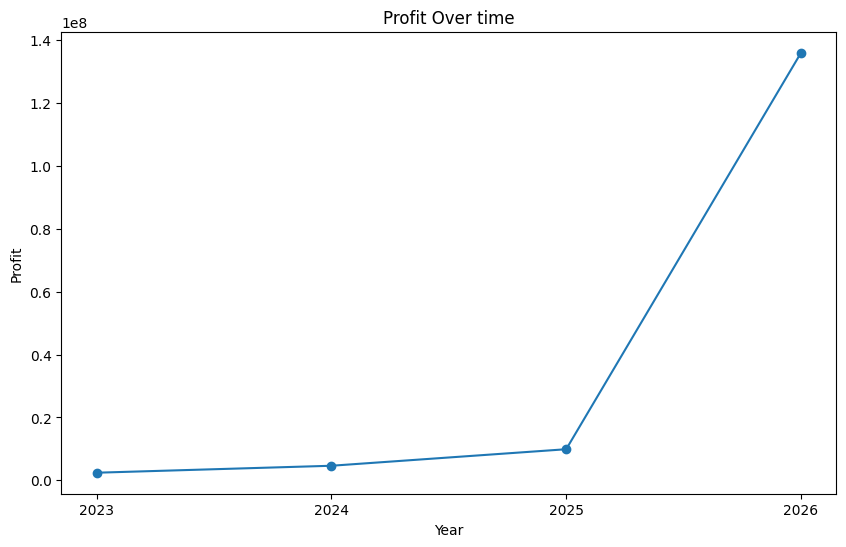

In [ ]:
# visualisasi
trends_over_time = fmcg_copy.groupby('year')['profit'].sum().reset_index()

plt.figure(figsize=(10,6))
plt.plot(trends_over_time['year'], trends_over_time['profit'], marker='o')
plt.title('Profit Over time')
plt.xlabel('Year')
plt.ylabel('Profit')
plt.xticks(trends_over_time['year'])
plt.show()

**insight** profit dari tahun ke tahun selalu naik dan puncaknya berada di tahun 2025 - 2026. bisnis ini dinilai cukup positif

## berdasarkan sales

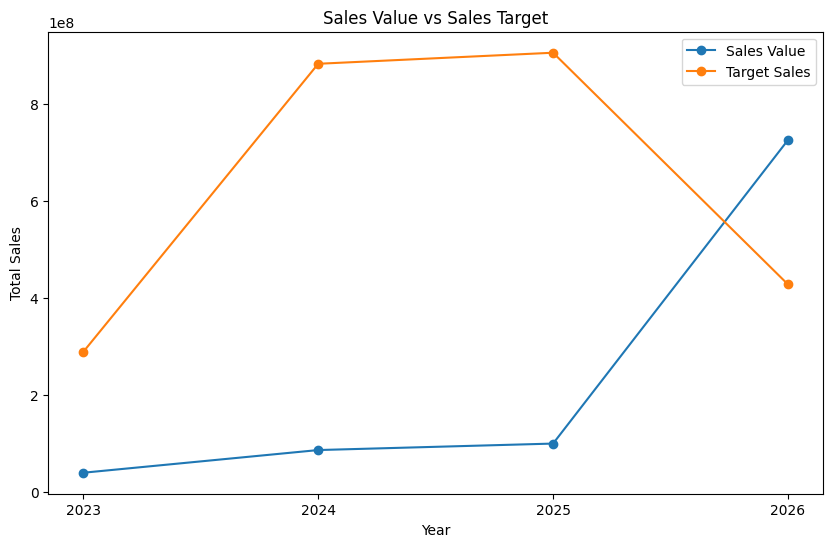

In [ ]:
# 2. Visualiassi sales value vs sales target setiap tahun
gap_sales = fmcg_copy.groupby('year')[['Sales_Value','Target_Sales']].sum()

plt.figure(figsize=(10,6))
plt.plot(gap_sales.index, gap_sales['Sales_Value'], label='Sales Value', marker='o')
plt.plot(gap_sales.index, gap_sales['Target_Sales'], label='Target Sales', marker='o')
plt.title('Sales Value vs Sales Target')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(gap_sales.index)
plt.legend()
plt.show()

**insight** dari awal 2023 target sales yang ditetapkan oleh perusahaan sangat tinggi, meskipun sales actual perlahan meningkat tapi tidak bisa mencapai target yang terlalu tinggi. oleh akrena itu, di tahun 2024 - 2025 persent target sales dinaikkan sedikit saja. karena mungkin perusahaan menerapkan target sales yang sangat tinggi, 2025 - 2026 menurunkan target sales yang cukup drastis dari >800 jt ke 300 jt an. akhirnya tahun 2025 akhir - 2066 berhasil melampaui target sales.

## berdasarkan return

In [ ]:
# extract by month
fmcg_copy['month'] = fmcg_copy['sales_date'].dt.month

In [ ]:
# 3. return per month where return_flag = Y
return_per_month = fmcg_copy.groupby('month')['return_flag'].apply(lambda x:(x=='Y').sum())
return_per_month

,return_flag
month,
1,289
2,294
3,305
4,294
5,300
6,218
7,217
8,205
9,270


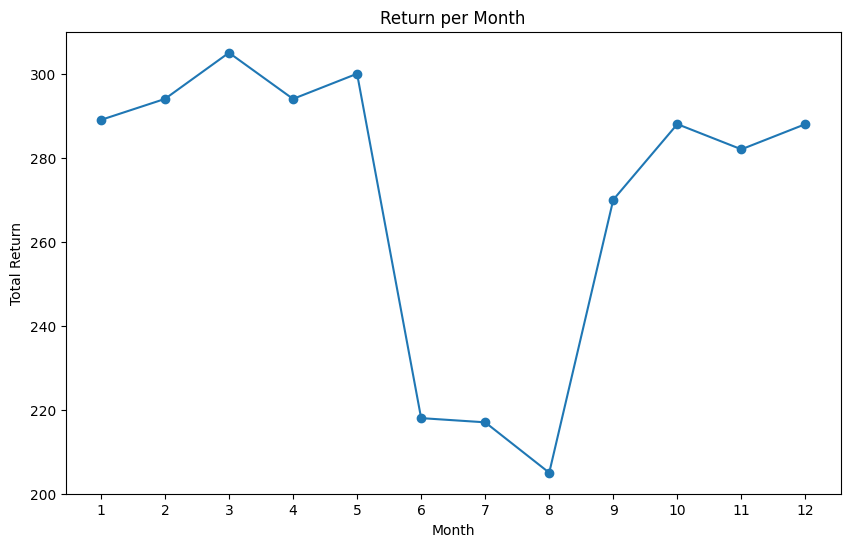

In [ ]:
# visualiasasi
return_per_month = fmcg_copy.groupby('month')['return_flag'].apply(lambda x:(x=='Y').sum())

plt.figure(figsize=(10,6))
plt.plot(return_per_month.index, return_per_month.values, marker='o')
plt.title('Return per Month')
plt.xlabel('Month')
plt.ylabel('Total Return')
plt.xticks(return_per_month.index)
plt.show()

**Insight** : berdasarkan hasil analisi total return sudah sangat baik pada bulan 6 - 8 karena terjadi penurunan secara signifikan. tapi dari bulan 8 - 9 terjadi kenaikan yang tinggi. ini dapat menjadi bagian dari target analisis. **apa yang menyebabkan kenaikan sangat tinggi pada bulan 8 dan selanjutnya. atau faktor apa yang mempengaruhi penurunan return**

In [ ]:
# 3. return per year where return_flag = Y
return_per_year = fmcg_copy.groupby('year')['return_flag'].apply(lambda x:(x=='Y').sum())
return_per_year

,return_flag
year,
2023,367
2024,1158
2025,1169
2026,556


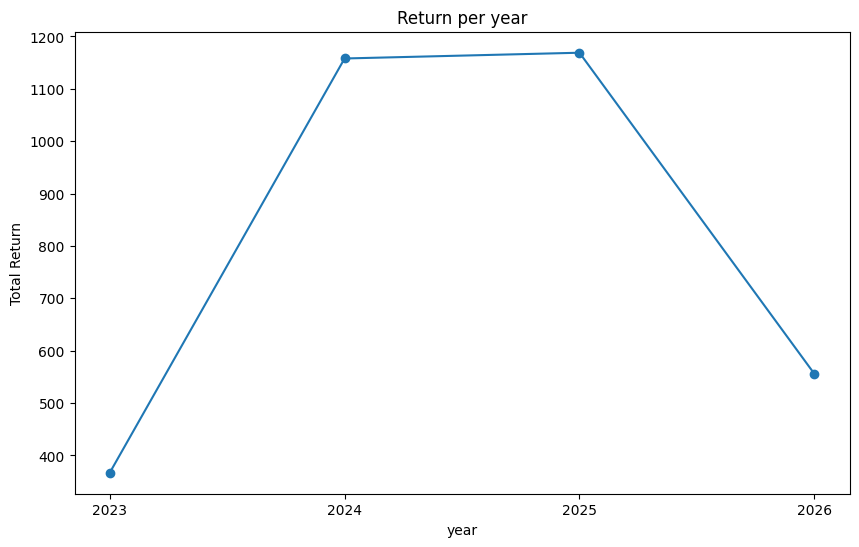

In [ ]:
# visualiasasi
return_per_year = fmcg_copy.groupby('year')['return_flag'].apply(lambda x:(x=='Y').sum())

plt.figure(figsize=(10,6))
plt.plot(return_per_year.index, return_per_year.values, marker='o')
plt.title('Return per year')
plt.xlabel('year')
plt.ylabel('Total Return')
plt.xticks(return_per_year.index)
plt.show()

In [ ]:
# 4. Cari tahu kategori produk apa yang banyak di return di setiap tahun
return_category_by_year = fmcg_copy[fmcg_copy['return_flag'] == 'Y'].groupby(['year', 'sku_category']).size()
return_category_by_year

year  sku_category 
2023  Food             221
      Household         69
      Personal Care     77
2024  Food             703
      Household        236
      Personal Care    219
2025  Food             700
      Household        235
      Personal Care    234
2026  Food             332
      Household        103
      Personal Care    121
dtype: int64

**Insight** : ternyata produk yang paling banyak return makanan. pada tahun 2025 -2026 terjadi penurunan signifikan terhadap jumlah return setiap category. artinya return barang berdampak pada sales target yang telah tercapai

In [ ]:
# 5. check sku_category berdasarkan sales_channel dimana return flag = Y dan terjadi di tahun 2025 - 2026
filtered_data = fmcg_copy[
    (fmcg_copy['year'].isin([2025, 2026])) &
    (fmcg_copy['return_flag'] == 'Y')
]

# group by 'Sales_Channel' and 'sku_category' and count the returns
channel_return_by_year = filtered_data.groupby(['Sales_Channel', 'sku_category']).size()
channel_return_by_year

Sales_Channel  sku_category 
Distributor    Food             346
               Household        118
               Personal Care    113
Offline        Food             337
               Household        118
               Personal Care    113
Online         Food             349
               Household        102
               Personal Care    129
dtype: int64

**Insight** : ternyata food return paling dari 3 sales channel memiliki jumlah yang tidak beda jauh. **kategori 'food'** karena produk makanan jadi riskan apabila di jual berdasarkan sales channel online dan distributor. **kategori 'Household'** sedikit janggal karena offline channel malah paling banyak dibanding online dan distributor. **kategori 'personal care'** pemasaran offline lebih minim resiko return karena mungkin bisa testing secara personal.

 bagaimana jika dilihat berdasarkan outlet_type?

----------
Outlet_Type: Jenis tipe toko ritel yang membeli produk (contoh:  General Trade untuk toko kelontong konvensional,  Modern Trade untuk minimarket/supermarket modern).

In [ ]:
# 6. check sku_category berdasarkan outlet_type dimana return flag = Y dan terjadi di tahun 2025 - 2026
filtered_data = fmcg_copy[
    (fmcg_copy['year'].isin([2025, 2026])) &
    (fmcg_copy['return_flag'] == 'Y')
]

# group by 'outlet_type' and 'sku_category' and count the returns
outlet_return_by_year = filtered_data.groupby(['outlet_type', 'sku_category']).size()
outlet_return_by_year

outlet_type    sku_category 
General Trade  Food             510
               Household        152
               Personal Care    178
Modern Trade   Food             522
               Household        186
               Personal Care    177
dtype: int64

## Berdasarkan Customer

In [ ]:
fmcg_copy.head()

,Invoice_No,retailer_id,sales_date,city,sku_category,brand,Units_Sold,Unit_Price,discount_pct,Sales_Value,...,outlet_type,Sales_Channel,Customer_Age,loyalty_flag,return_flag,Target_Sales,profit,age_category,year,month
0,FMC-000001,RTL1965,2025-08-21,Bandung,Food,Brand B,1,797.24,0.50,914.85,...,General Trade,Distributor,67,N,Y,108312,2.00,Old,2025,8
1,FMC-000002,Unknown,2025-08-08,Jakarta,Household,Brand A,3573,131.59,0.05,446663.00,...,General Trade,Online,36,N,N,490592,204005.00,Adult,2025,8
2,FMC-000003,Unknown,2024-09-12,Yogyakarta,Food,Brand B,13,517.66,0.20,5383.66,...,General Trade,Online,56,N,Y,432032,1818.71,Old,2024,9
3,FMC-000004,RTL1193,2025-03-31,Yogyakarta,Household,Brand B,8,321.69,0.95,128.68,...,General Trade,Offline,67,N,N,71174,-35.71,Old,2025,3
4,FMC-000005,RTL3648,2024-03-26,Bandung,Personal Care,Brand A,10,877.23,0.20,7017.84,...,General Trade,Online,58,Y,Y,250452,1912.60,Old,2024,3


In [ ]:
# 1. Berapa customer menjadi loyalty_flag = Y?
customer_loyalty = fmcg_copy.groupby('loyalty_flag')['retailer_id'].nunique()
customer_loyalty

,retailer_id
loyalty_flag,
N,3143
Y,2157


In [ ]:
# 2.  Rata-rata retailer_id dari kota mana berdasrkan loyalty_flag
retailer_by_city = fmcg_copy.groupby(['city','loyalty_flag'])['retailer_id'].nunique()
retailer_by_city

city        loyalty_flag
Bandung     N               1231
            Y                684
Jakarta     N               1306
            Y                686
Surabaya    N               1283
            Y                701
Yogyakarta  N               1300
            Y                716
Name: retailer_id, dtype: int64

**Insight** customer loyal : di yogyakarta,dan bandung memiliki potensi untuk meningkatkan pelanggan loyal

In [ ]:
# 3. melihat apakah pelanggan loyal dan tidak juga sama-sama diberi diskon besar (>50%)
# Filter for entries with discount_pct > 50%
discounted_customers = fmcg_copy[fmcg_copy['discount_pct'] > 0.5]

# Group by loyalty_flag to see the distribution
discount_distribution_by_loyalty = discounted_customers.groupby('loyalty_flag').size()
display(discount_distribution_by_loyalty)

,0
loyalty_flag,
N,1462
Y,787


**Insight** customer loyal : perusahaan memberikan diskon besar > 50% kepada justru kepada customer yang tidak loyal

In [ ]:
# 4. retailer_id memiliki outlet type apa? GT/ MT?
retailer_by_outlet = fmcg_copy.groupby(['outlet_type','loyalty_flag'])['retailer_id'].nunique()
retailer_by_outlet

outlet_type    loyalty_flag
General Trade  N               2152
               Y               1261
Modern Trade   N               2161
               Y               1296
Name: retailer_id, dtype: int64

In [ ]:
# 5. customer berdasarkan sales channel dan loyalty flag
pretailer_by_channel = fmcg_copy.groupby(['Sales_Channel', 'loyalty_flag'])['retailer_id'].nunique()
pretailer_by_channel

Sales_Channel  loyalty_flag
Distributor    N               1615
               Y                924
Offline        N               1605
               Y                888
Online         N               1602
               Y                896
Name: retailer_id, dtype: int64

In [ ]:
# 6. Berapa keuntungan yang didapatkan perusahaan untuk 1 customer?
profit_per_customer = fmcg_copy.groupby(['retailer_id', 'loyalty_flag'])['profit'].sum()
profit_per_customer.sort_values(ascending=False).head(5)

,,profit
retailer_id,loyalty_flag,
RTL2357,N,1.466677e+08
Unknown,N,3.135517e+06
RTL1269,N,2.916430e+06
RTL1272,N,1.139671e+06
RTL4583,N,1.056419e+06


profit paling menguntungkan malah berada pada customer yang tidak mendaftar sebagai member

In [ ]:
# 8. rata-rata umur cutomer yang loyal
loyal_by_age = fmcg_copy[fmcg_copy['loyalty_flag'] == 'Y'].groupby('age_category').size()
loyal_by_age

,0
age_category,
Adult,919
Old,925
Senior,903
Young Adult,491


loyal customer paling banyak berada pada kategori old atau memiliki umur lebih dari 56 hungga 70 tahun

## Berdasarkan Brand

In [ ]:
fmcg_copy.head()

,Invoice_No,retailer_id,sales_date,city,sku_category,brand,Units_Sold,Unit_Price,discount_pct,Sales_Value,...,outlet_type,Sales_Channel,Customer_Age,loyalty_flag,return_flag,Target_Sales,profit,age_category,year,month
0,FMC-000001,RTL1965,2025-08-21,Bandung,Food,Brand B,1,797.24,0.50,914.85,...,General Trade,Distributor,67,N,Y,108312,2.00,Old,2025,8
1,FMC-000002,Unknown,2025-08-08,Jakarta,Household,Brand A,3573,131.59,0.05,446663.00,...,General Trade,Online,36,N,N,490592,204005.00,Adult,2025,8
2,FMC-000003,Unknown,2024-09-12,Yogyakarta,Food,Brand B,13,517.66,0.20,5383.66,...,General Trade,Online,56,N,Y,432032,1818.71,Old,2024,9
3,FMC-000004,RTL1193,2025-03-31,Yogyakarta,Household,Brand B,8,321.69,0.95,128.68,...,General Trade,Offline,67,N,N,71174,-35.71,Old,2025,3
4,FMC-000005,RTL3648,2024-03-26,Bandung,Personal Care,Brand A,10,877.23,0.20,7017.84,...,General Trade,Online,58,Y,Y,250452,1912.60,Old,2024,3


In [ ]:
# jumlah sku untuk setiap brand
sku_brand = fmcg_copy.groupby('brand')['sku_category'].nunique()
sku_brand

,sku_category
brand,
Brand A,3
Brand B,3
Brand C,3


In [ ]:
# kategori produk dri brand apa yang banyak habis?
brand_product_sold = fmcg_copy.groupby(['brand','sku_category'])['Units_Sold'].sum()
brand_product_sold

brand    sku_category 
Brand A  Food              88776
         Household         16728
         Personal Care     11562
Brand B  Food             149005
         Household         51799
         Personal Care     60406
Brand C  Food              71157
         Household         15047
         Personal Care     28280
Name: Units_Sold, dtype: int64

In [ ]:
#  brand apa yang banyak return?
brand_product_return = fmcg_copy.groupby('brand')['return_flag'].apply(lambda x: (x=='Y').sum())
brand_product_return

,return_flag
brand,
Brand A,836
Brand B,1646
Brand C,768


In [ ]:
# Berapa revenue yang diperoleh setiap brand per tahun?
brand_revenue = fmcg_copy.groupby(['brand'])['Sales_Value'].sum()
brand_revenue

,Sales_Value
brand,
Brand A,6.030718e+07
Brand B,6.085666e+08
Brand C,2.836634e+08


In [ ]:
# Berapa revenue yang diperoleh setiap brand per tahun? dari sku_category apa yang paling menguntungkan?
brand_revenue = fmcg_copy.groupby(['brand','year','sku_category'])['Sales_Value'].sum()
brand_revenue

brand    year  sku_category 
Brand A  2023  Food             4.807799e+06
               Household        2.020658e+05
               Personal Care    5.923060e+05
         2024  Food             1.284446e+07
               Household        5.514232e+06
               Personal Care    5.003727e+06
         2025  Food             1.555791e+07
               Household        5.233690e+06
               Personal Care    3.746848e+06
         2026  Food             6.184275e+06
               Household        2.907275e+05
               Personal Care    3.291437e+05
Brand B  2023  Food             1.679156e+07
               Household        5.123027e+06
               Personal Care    5.910437e+06
         2024  Food             1.908019e+07
               Household        8.537918e+06
               Personal Care    9.582268e+06
         2025  Food             2.698208e+07
               Household        6.744743e+06
               Personal Care    1.671453e+07
         2026  Food             1.578850e+07
               Household        7.747223e+07
               Personal Care    3.998391e+08
Brand C  2023  Food             5.634000e+06
               Household        5.112321e+05
               Personal Care    2.190568e+05
         2024  Food             1.979370e+07
               Household        4.845103e+06
               Personal Care    1.369870e+06
         2025  Food             1.420831e+07
               Household        4.388029e+06
               Personal Care    6.368011e+06
         2026  Food             2.211719e+08
               Household        8.541249e+05
               Personal Care    4.300049e+06
Name: Sales_Value, dtype: float64

# RFM Matrix

* Recency (R) → Seberapa baru pelanggan melakukan transaksi.
* Frequency (F) → Seberapa sering pelanggan bertransaksi.
* Monetary (M) → Berapa besar nilai transaksi pelanggan.

In [ ]:
# 1. Menentukan tanggal acuan
fmcg_copy['sales_date'].max() # mk snapshot date 2026-06-20

snapshot_date = fmcg['sales_date'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2026-06-20 00:00:00')

In [ ]:
# menghitung RFM
rfm = fmcg_copy.groupby('retailer_id').agg({
    'sales_date': lambda x: (snapshot_date - x.max()).days,
    'Invoice_No' : 'nunique',
    'Sales_Value' : 'sum'
}).reset_index()

# mengubah nama kolom
rfm.columns = [
    'retailer_id',
    'recency',
    'frequency',
    'monetary'
]

In [ ]:
rfm.head()

,retailer_id,recency,frequency,monetary
0,RTL1000,242,5,29418.03
1,RTL1001,664,1,1054.81
2,RTL1002,420,1,49.08
3,RTL1003,227,3,27764.02
4,RTL1004,375,1,2780.64


In [ ]:
#scoring rfm,
#recency : semakin kecil scorenya smakin baik.
rfm['r_score'] = pd.qcut(
    rfm['recency'],
    5,
    labels=[5,4,3,2,1]
)

#frequency : semakin besar scorenya smakin baik.
rfm['f_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

#monetary : semakin besar scorenya smakin baik.
rfm['m_score'] = pd.qcut(
    rfm['monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
# score total
rfm['rfm_score'] = (
    rfm['r_score'].astype(str) +
    rfm['f_score'].astype(str) +
    rfm['m_score'].astype(str)
)

In [ ]:
# Segmentasi pelanggan
def segment(row):
  if row['rfm_score'] == '555':
    return 'Champion'
  elif row['r_score'] >= 4 and row['f_score'] >= 4 :
    return 'Loyal Customer'
  elif row['r_score'] >= 4:
    return 'Recent Customer'
  elif row['r_score'] <= 2:
    return 'At Risk'
  else:
    return 'Others'
rfm['segment'] = rfm.apply(segment,axis=1)

In [ ]:
rfm.head()

,retailer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,RTL1000,242,5,29418.03,3,5,5,355,Others
1,RTL1001,664,1,1054.81,1,1,1,111,At Risk
2,RTL1002,420,1,49.08,2,1,1,211,At Risk
3,RTL1003,227,3,27764.02,3,3,5,335,Others
4,RTL1004,375,1,2780.64,2,1,2,212,At Risk


In [ ]:
# jumlah pelanggan per segment
rfm['segment'].value_counts()

,count
segment,
At Risk,1439
Others,717
Loyal Customer,683
Recent Customer,642
Champion,124


In [ ]:
# monetary penjualan per segmen
rfm.groupby('segment')['monetary'].sum()

,monetary
segment,
At Risk,6.687320e+07
Champion,4.459296e+07
Loyal Customer,6.761019e+08
Others,6.827721e+07
Recent Customer,9.669188e+07


In [ ]:
# rata-rata transaksi
rfm.groupby('segment').agg({
    'frequency' : 'mean',
    'monetary' : 'mean'
})

,frequency,monetary
segment,,
At Risk,1.910354,46471.992001
Champion,9.983871,359620.640403
Loyal Customer,3.900439,989900.339941
Others,2.785216,95226.231102
Recent Customer,1.814642,150610.406402


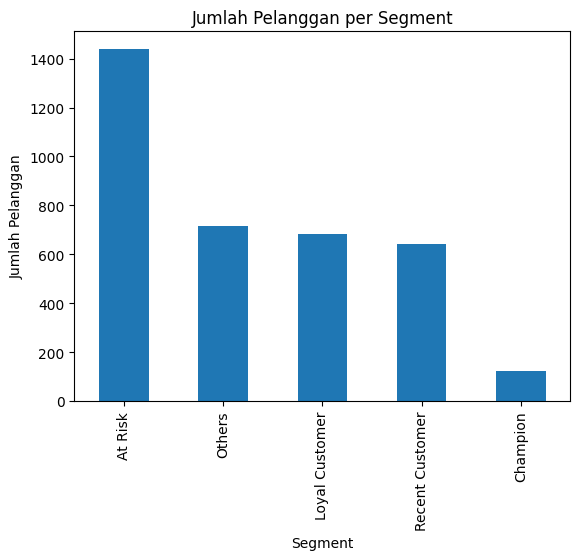

In [ ]:
#jumlah pelanggan
rfm['segment'].value_counts().plot.bar()
plt.title('Jumlah Pelanggan per Segment')
plt.xlabel('Segment')
plt.ylabel('Jumlah Pelanggan')
plt.show()

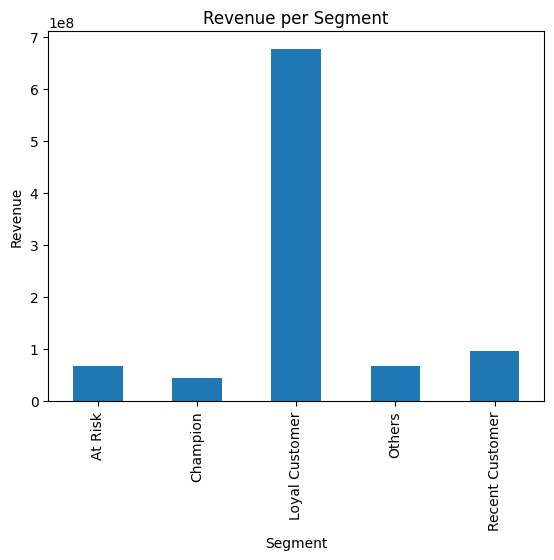

In [ ]:
# monetary per segment
rfm.groupby('segment')['monetary'].sum().plot.bar()
plt.title('Revenue per Segment')
plt.xlabel('Segment')
plt.ylabel('Revenue')
plt.show()
#